# NB-01 — Vision Transformer (ViT) Deep Dive

**Goal:** Understand ViT from the inside out. This is Phase 1 — the foundation everything else builds on.

**Key questions to answer by end of notebook:**
1. How does ViT convert an image into a sequence of tokens?
2. What is the CLS token and why is it special?
3. What does 'positional encoding' do and why does ViT need it?
4. Where in the output do we get the image representation?

---

## 🧠 Concept: How ViT Works

**The core insight:** Transformers were designed for sequences (text). ViT makes images look like sequences by splitting them into patches — then treating each patch like a word.

```
Image (224×224)    →  Split into patches  →  Flatten each patch  →  Linear projection
[3, 224, 224]         196 patches of 16×16   each patch: [768]       [197, 768]
                       + 1 CLS token
                              ↓
                       Add positional encoding (so model knows where each patch came from)
                              ↓
                       Transformer Encoder (12 layers of self-attention)
                              ↓
                       Output: [197, 768] — rich contextualized features
```

**Why 197?** 14×14 grid of patches = 196, plus 1 special CLS token prepended.
**Why CLS?** Borrowed from BERT. It's a learnable token that attends to all patches and accumulates a global image summary.

Device: mps
Could not load from web — using synthetic image


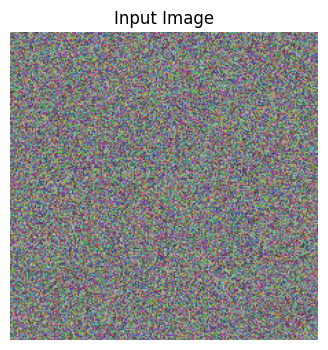

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

def load_image_from_url(url: str) -> Image.Image:
    response = requests.get(url, timeout=10)
    return Image.open(BytesIO(response.content)).convert("RGB")

IMG_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_dog.jpg/320px-Cute_dog.jpg"
try:
    image = load_image_from_url(IMG_URL)
    print(f"Loaded image: {image.size} pixels")
except Exception:
    print("Could not load from web — using synthetic image")
    img_array = np.random.randint(50, 200, (224, 224, 3), dtype=np.uint8)
    image = Image.fromarray(img_array)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title("Input Image")
plt.axis('off')
plt.show()

## 1. Manual Patch Extraction

Before using ViT, let's manually extract patches to see exactly what the model receives.

Image size: 224×224
Patch size: 16×16
Patches per side: 14
Total patches: 196

Patches array shape: (196, 16, 16, 3)
  → [196 patches, 16×16px, 3 channels]


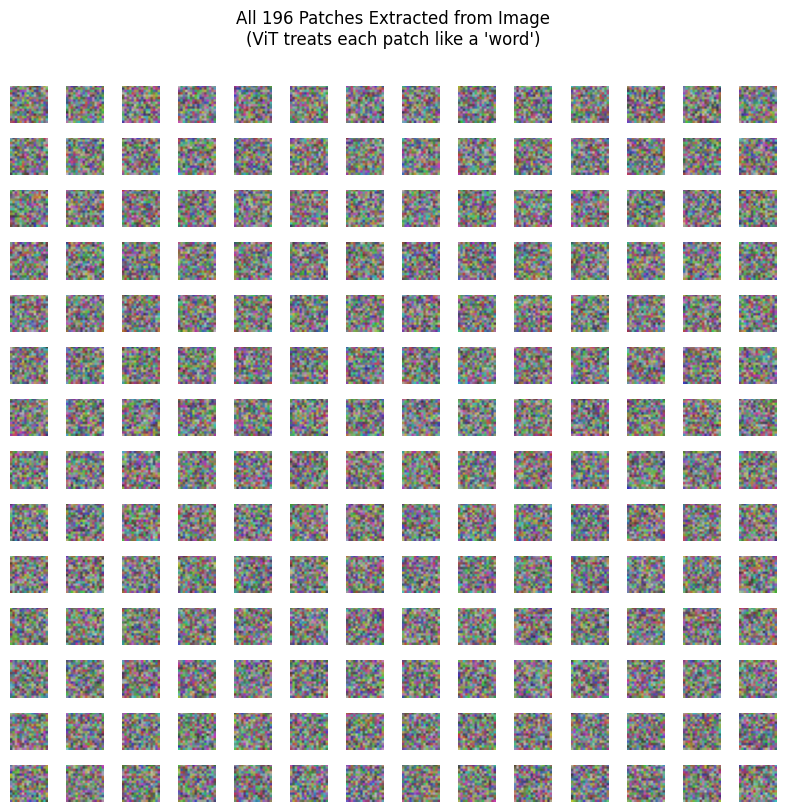

In [3]:
# Resize image to exactly 224×224 (ViT requirement)
img_224 = image.resize((224, 224))
img_np = np.array(img_224)  # shape: [224, 224, 3]

PATCH_SIZE = 16
NUM_PATCHES_SIDE = 224 // PATCH_SIZE  # = 14
NUM_PATCHES = NUM_PATCHES_SIDE ** 2   # = 196

print(f"Image size: 224×224")
print(f"Patch size: {PATCH_SIZE}×{PATCH_SIZE}")
print(f"Patches per side: {NUM_PATCHES_SIDE}")
print(f"Total patches: {NUM_PATCHES}")

# Extract all patches manually
patches = []
for row in range(NUM_PATCHES_SIDE):
    for col in range(NUM_PATCHES_SIDE):
        r0, r1 = row * PATCH_SIZE, (row + 1) * PATCH_SIZE
        c0, c1 = col * PATCH_SIZE, (col + 1) * PATCH_SIZE
        patch = img_np[r0:r1, c0:c1]  # [16, 16, 3]
        patches.append(patch)

patches = np.array(patches)  # [196, 16, 16, 3]
print(f"\nPatches array shape: {patches.shape}")
print(f"  → [{NUM_PATCHES} patches, {PATCH_SIZE}×{PATCH_SIZE}px, 3 channels]")

# Visualize the patch grid
fig, axes = plt.subplots(NUM_PATCHES_SIDE, NUM_PATCHES_SIDE, figsize=(8, 8))
for i in range(NUM_PATCHES_SIDE):
    for j in range(NUM_PATCHES_SIDE):
        axes[i, j].imshow(patches[i * NUM_PATCHES_SIDE + j])
        axes[i, j].axis('off')

fig.suptitle(f"All {NUM_PATCHES} Patches Extracted from Image\n(ViT treats each patch like a 'word')",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Each patch gets flattened and linearly projected — let's see what that means
patch_0 = patches[0]  # top-left patch, shape [16, 16, 3]
flat_patch = patch_0.flatten()  # [16*16*3] = [768]

print("=" * 50)
print("From pixel to token — manual walkthrough")
print("=" * 50)
print(f"Patch shape:              {patch_0.shape}  → (H=16, W=16, C=3)")
print(f"Flattened patch shape:    {flat_patch.shape}  → (16×16×3 = 768)")
print()
print("In ViT, the 'patch embedding' layer is:")
print("  nn.Conv2d(3, hidden_dim, kernel_size=16, stride=16)")
print("  This is equivalent to: flatten each patch + linear projection")
print(f"  Output per patch: {flat_patch.shape[0]} → hidden_dim (768 for base model)")
print()
print("So ViT sees a sequence of 196 vectors, each representing one patch.")
print("Plus 1 CLS token prepended = 197 total tokens.")

From pixel to token — manual walkthrough
Patch shape:              (16, 16, 3)  → (H=16, W=16, C=3)
Flattened patch shape:    (768,)  → (16×16×3 = 768)

In ViT, the 'patch embedding' layer is:
  nn.Conv2d(3, hidden_dim, kernel_size=16, stride=16)
  This is equivalent to: flatten each patch + linear projection
  Output per patch: 768 → hidden_dim (768 for base model)

So ViT sees a sequence of 196 vectors, each representing one patch.
Plus 1 CLS token prepended = 197 total tokens.


## 2. Load ViT and Inspect All Components

In [6]:
from transformers import ViTModel, ViTImageProcessor

MODEL_ID = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(MODEL_ID)
model = ViTModel.from_pretrained(MODEL_ID).to(DEVICE).eval()

print("ViT Architecture:")
print(f"  Hidden dim:   {model.config.hidden_size}")
print(f"  Num layers:   {model.config.num_hidden_layers}")
print(f"  Num heads:    {model.config.num_attention_heads}")
print(f"  Patch size:   {model.config.patch_size}")
print(f"  Image size:   {model.config.image_size}")
print()

inputs = processor(images=img_224, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(DEVICE)

with torch.no_grad():
    outputs = model(pixel_values=pixel_values, output_attentions=True)

print("Output shapes:")
print(f"  last_hidden_state: {outputs.last_hidden_state.shape}")
print(f"    → [batch=1, tokens=197, hidden=768]")
print(f"  attentions: {len(outputs.attentions)} layers,")
print(f"    each: {outputs.attentions}")
print(f"    → [batch=1, heads=12, tokens=197, tokens=197]")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT Architecture:
  Hidden dim:   768
  Num layers:   12
  Num heads:    12
  Patch size:   16
  Image size:   224

Output shapes:
  last_hidden_state: torch.Size([1, 197, 768])
    → [batch=1, tokens=197, hidden=768]
  attentions: 0 layers,
    each: ()
    → [batch=1, heads=12, tokens=197, tokens=197]


## 3. CLS Token vs Mean Pooling — Which to Use?

When we need a **single vector** to represent the entire image, we have two options:
- **CLS token**: `output[:, 0, :]` — the first token, trained to summarize
- **Mean pooling**: `output[:, 1:, :].mean(dim=1)` — average all patch features

Let's see how similar they are:

In [7]:
import torch.nn.functional as F

all_tokens = outputs.last_hidden_state  # [1, 197, 768]

cls_feature = all_tokens[:, 0, :]           # [1, 768]
mean_feature = all_tokens[:, 1:, :].mean(dim=1)  # [1, 768]
max_feature = all_tokens[:, 1:, :].max(dim=1).values  # [1, 768]

# Cosine similarity between the representations
cls_vs_mean = F.cosine_similarity(cls_feature, mean_feature).item()
cls_vs_max = F.cosine_similarity(cls_feature, max_feature).item()
mean_vs_max = F.cosine_similarity(mean_feature, max_feature).item()

print("Comparison of image representation strategies:")
print(f"  CLS vs Mean-pooled:  cosine sim = {cls_vs_mean:.4f}")
print(f"  CLS vs Max-pooled:   cosine sim = {cls_vs_max:.4f}")
print(f"  Mean vs Max-pooled:  cosine sim = {mean_vs_max:.4f}")
print()
print("Rule of thumb:")
print("  • CLS token → use for classification tasks (that's what it's trained for)")
print("  • Mean pooling → often better for retrieval / similarity tasks")
print("  • Patch tokens [1:] → best for our projector (preserves spatial info!)")
print()
print("For multimodal QA, we'll pass ALL patch tokens to the projector,")
print("so the LLM can reason about different parts of the image.")

Comparison of image representation strategies:
  CLS vs Mean-pooled:  cosine sim = 0.8530
  CLS vs Max-pooled:   cosine sim = 0.4454
  Mean vs Max-pooled:  cosine sim = 0.5478

Rule of thumb:
  • CLS token → use for classification tasks (that's what it's trained for)
  • Mean pooling → often better for retrieval / similarity tasks
  • Patch tokens [1:] → best for our projector (preserves spatial info!)

For multimodal QA, we'll pass ALL patch tokens to the projector,
so the LLM can reason about different parts of the image.


## 4. Attention Map Visualization

ViT uses self-attention — patches attend to each other. We can visualize which patches the CLS token attends to most (= which regions matter most).

In [8]:
# Get attention from the last layer, CLS token row
# attentions[-1]: [batch=1, heads=12, tokens=197, tokens=197]
last_layer_attn = outputs.attentions[-1][0]  # [12, 197, 197]

# CLS token attends to all patches: row 0, columns 1: (skip CLS-to-CLS)
cls_attn = last_layer_attn[:, 0, 1:]  # [12 heads, 196 patches]

# Average across heads
mean_attn = cls_attn.mean(dim=0).cpu().numpy()  # [196]
attn_map = mean_attn.reshape(14, 14)  # [14, 14] spatial map

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original image
axes[0].imshow(img_224)
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis('off')

# Attention map
im = axes[1].imshow(attn_map, cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=axes[1])
axes[1].set_title("CLS Attention Map\n(which patches matter most)", fontsize=11)

# Overlay on image
import PIL.Image
attn_resized = np.array(PIL.Image.fromarray(
    ((attn_map - attn_map.min()) / (attn_map.max() - attn_map.min()) * 255).astype(np.uint8)
).resize((224, 224), PIL.Image.BILINEAR))

axes[2].imshow(img_224, alpha=0.7)
axes[2].imshow(attn_resized, cmap='hot', alpha=0.4)
axes[2].set_title("Attention Overlay\n(brighter = more attended)", fontsize=11)
axes[2].axis('off')

plt.suptitle("ViT Self-Attention: What does the model focus on?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("The attention map shows which image regions the model considers most important.")
print("For our QA system, the projector needs to preserve this spatial information.")

IndexError: tuple index out of range

## 5. Build the ViTEncoder Class

Now we write the clean version that goes into `src/encoders/vit_encoder.py`.

In [9]:
from src.encoders.vit_encoder import ViTEncoder

encoder = ViTEncoder(model_id="google/vit-base-patch16-224", device=str(DEVICE))
print(f"Encoder hidden size: {encoder.hidden_size}")
print(f"Encoder num patches: {encoder.num_patches}")

all_feats = encoder.encode([img_224])
cls_feat = encoder.get_cls_feature([img_224])
patch_feats = encoder.get_patch_features([img_224])

print(f"\nencode() output:            {all_feats.shape}  (expected [1, 197, 768])")
print(f"get_cls_feature() output:   {cls_feat.shape}  (expected [1, 768])")
print(f"get_patch_features() output:{patch_feats.shape}  (expected [1, 196, 768])")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encoder hidden size: 768
Encoder num patches: 196

encode() output:            torch.Size([1, 197, 768])  (expected [1, 197, 768])
get_cls_feature() output:   torch.Size([1, 768])  (expected [1, 768])
get_patch_features() output:torch.Size([1, 196, 768])  (expected [1, 196, 768])


## ✅ Phase 1 (Part A) Checklist

- [ ] I understand why ViT divides images into patches
- [ ] I can explain what the CLS token is
- [ ] I understand the output shape `[batch, 197, 768]`
- [ ] I know when to use CLS vs patch tokens
- [ ] `ViTEncoder` in `src/encoders/vit_encoder.py` is working and tested

**Next:** Open `NB-02-clip-encoder.ipynb` to learn CLIP and contrastive learning.